In [17]:
# import os
# import shutil
# from pathlib import Path

# for folder in os.listdir("./"):
#     if folder == "dataset":
#         print("Dataset folder, continue..") 
#         continue
#     if not Path(f"./{folder}").is_dir(): continue
#     if "datatest_training" in os.listdir(f"./{folder}"):
#         shutil.rmtree(f"./{folder}/datatest_training")

#     print(os.listdir(f"./{folder}"))
#     # os.rmdir(f"./{folder}/datatest_test")

['matrici_confusione', 'jupyter_live_log.txt', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint', 'FL T19.ipynb']
['matrici_confusione', 'jupyter_live_log-Copy1.txt', 'jupyter_live_log.txt', 'results', 'process_result.ipynb', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint', 'FL test1_4.ipynb']
['matrici_confusione', 'jupyter_live_log.txt', 'results', 'process_result.ipynb', 'FL T27.ipynb', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint']
['matrici_confusione', 'FL TM14.ipynb', 'jupyter_live_log.txt', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint']
['matrici_confusione', 'process_result_f12.ipynb', 'jupyter_live_log-Copy1.txt', 'jupyter_live_log.txt', 'FL test1.2.ipynb', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint']
['FL T1.3_SNE.ipynb', '.ipynb_checkpoints']
['matrici_confusione', 'FL test14.ipynb', 'jupyter_live_log.txt', 'logs', '.ipynb_checkpoints', 'dataloaders_indices', 'checkpoint', 'proce

In [1]:

from pathlib import Path
import re
import os
if not Path("./results/").is_dir():
    os.mkdir("./results/")

# Percorso del file di log
log_file_path = "./jupyter_live_log-Copy1.txt"

# Pattern regex per estrarre i dati
epoch_pattern = re.compile(r"Epoca\s+(\d+)\s+di\s+(\d+)\s*->\s*loss\s*-\s*accuracy\s*train\s*set:\s*([\d\.]+)\s+([\d\.]+)\s*->\s*loss\s*-\s*accuracy\s*validation\s*set:\s*([\d\.]+)\s+([\d\.]+)")
agent_pattern = re.compile(r"Agente (\d+) inizia l'addestramento")
round_pattern = re.compile(r"Round (\d+)/(\d+) iniziato...")
server_pattern = re.compile(r"agente (\d+) loss - accuracy sul server set ([\d\.]+) - ([\d\.]+)")
# agente 0 loss - accuracy sul server set 2.0137248127954246 - 0.5566
# Dizionario per contenere i dati per ogni client
clients_data = {}
server_data={}
# Lettura del file di log
with open(log_file_path, "r") as file:
    lines = file.readlines()
    
current_client = None
current_round = None
epoch_match = None
for line in lines:
    # client_match = client_pattern.search(line)
    agent_match = agent_pattern.search(line)
    round_match = round_pattern.search(line)
    epoch_match = epoch_pattern.search(line)
    server_match = server_pattern.search(line)
    if round_match:
        current_round = int(round_match.group(1))
        clients_data[current_round] = {}
        server_data[current_round] = {}
    if current_round and server_match:
        agente = server_match.group(1)
        server_data[current_round][agente] = {"loss":float(server_match.group(2)),
                                             "acc":float(server_match.group(3))
                                             }
        server_match = None

    if agent_match:
        current_client = int(agent_match.group(1))
        if current_client not in clients_data[current_round]:
            clients_data[current_round][current_client] = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

   

    if epoch_match:

        epoch = str(epoch_match.group(1))
        train_loss = float(epoch_match.group(3))
        train_acc = float(epoch_match.group(4))
        val_loss = float(epoch_match.group(5))
        val_acc = float(epoch_match.group(6))


    if epoch_match is not None:
    
        round_match = current_round

        clients_data[current_round][current_client]["epoch"].append(epoch)
        clients_data[current_round][current_client]["train_loss"].append(train_loss)
        clients_data[current_round][current_client]["train_acc"].append(train_acc)
        clients_data[current_round][current_client]["val_loss"].append(val_loss)
        clients_data[current_round][current_client]["val_acc"].append(val_acc)
    epoch_match = None
    round_match = None
    agent_match = None


FileNotFoundError: [Errno 2] No such file or directory: './jupyter_live_log-Copy1.txt'

CREAZIONE GRAFICI PER SINGOLO AGENTE PER ROUND

In [2]:
# # Creazione dei grafici per ogni client

# for round, data_ in clients_data.items():
    
#     for client, data in data_.items():
#         if client == 0:
#             plt.figure(figsize=(10, 5))
            
#             # Grafico della loss
#             plt.subplot(1, 2, 1)
#             plt.plot(data["epoch"], data["train_loss"], label="Train Loss", linestyle="-")
#             plt.plot(data["epoch"], data["val_loss"], label="Validation Loss", linestyle="--")
#             plt.xlabel("Epoch")
#             plt.ylabel("Loss")
#             plt.title(f"Client {client} - Loss Round {round}")
#             plt.legend()
            
#             # Grafico dell'accuracy
#             plt.subplot(1, 2, 2)
#             plt.plot(data["epoch"], data["train_acc"], label="Train Accuracy", linestyle="-")
#             plt.plot(data["epoch"], data["val_acc"], label="Validation Accuracy", linestyle="--")
#             plt.xlabel("Epoch")
#             plt.ylabel("Accuracy")
#             plt.title(f"Client {client} - Accuracy Round {round}")
#             plt.legend()
            
#             plt.tight_layout()
#             plt.show()


ANDAMENTO MEDIO PER OGNI CLIENT SU TUTTI I ROUND

In [3]:
# client_avg_loss = {}
# client_avg_accuracy = {}
# client_avg_val_loss={}
# client_avg_val_acc={}
# # Itera su ogni round e client per calcolare la media
# for round_id, clients in clients_data.items():
#     for client_id, metrics in clients.items():
#         if client_id not in client_avg_loss:
#             client_avg_loss[client_id] = []
#             client_avg_accuracy[client_id] = []
#             client_avg_val_loss[client_id] = []
#             client_avg_val_acc[client_id] = []
#         # Calcola la media delle loss e delle accuracy per ogni round
#         avg_loss = np.mean(metrics["train_loss"])
#         avg_accuracy = np.mean(metrics["train_acc"])
#         avg_val_loss = np.mean(metrics["val_loss"])
#         avg_val_acc = np.mean(metrics["val_acc"])
#         client_avg_val_loss[client_id].append(avg_val_loss)
#         client_avg_val_acc[client_id].append(avg_val_acc)
#         client_avg_loss[client_id].append(avg_loss)
#         client_avg_accuracy[client_id].append(avg_accuracy)
# rounds = range(1, len(next(iter(client_avg_loss.values()))) + 1)  # Numero di round

# for client_id in client_avg_loss.keys():
#     plt.figure(figsize=(12, 6))

#     plt.subplot(1,2,1)
#     plt.plot(rounds, client_avg_loss[client_id], label=f'Client {client_id}')
#     plt.plot(rounds, client_avg_val_loss[client_id], label=f'Client {client_id}')

#     plt.xlabel("Round")
#     plt.ylabel("Training Loss and Evaluation Loss")
#     plt.title("Andamento della Loss Media per Client")
#     plt.legend(loc="upper right", fontsize='small', ncol=2)
#     plt.grid()

#     plt.subplot(1,2,2)
#     plt.plot(rounds, client_avg_accuracy[client_id], label=f'Client {client_id}')
#     plt.plot(rounds, client_avg_val_acc[client_id], label=f'Client {client_id}')
#     plt.xlabel("Round")
#     plt.ylabel("Training Acc and Evaluation Acc")
#     plt.title("Andamento della Accuracy Media per Client")
#     plt.legend(loc="lower right", fontsize='small', ncol=2)
#     plt.grid()
#     plt.show()



ANDAMENTO Generale PER tutti i client su tutti i round

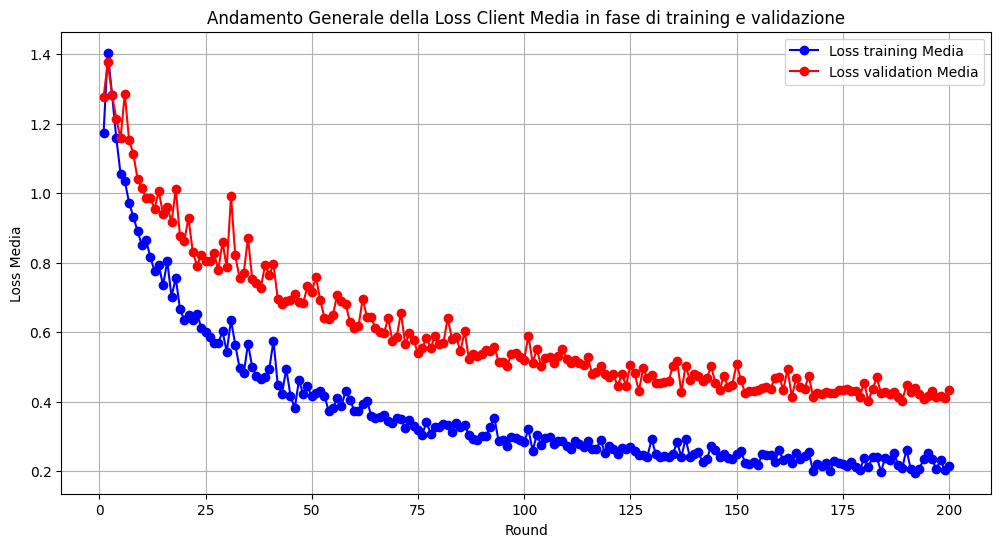

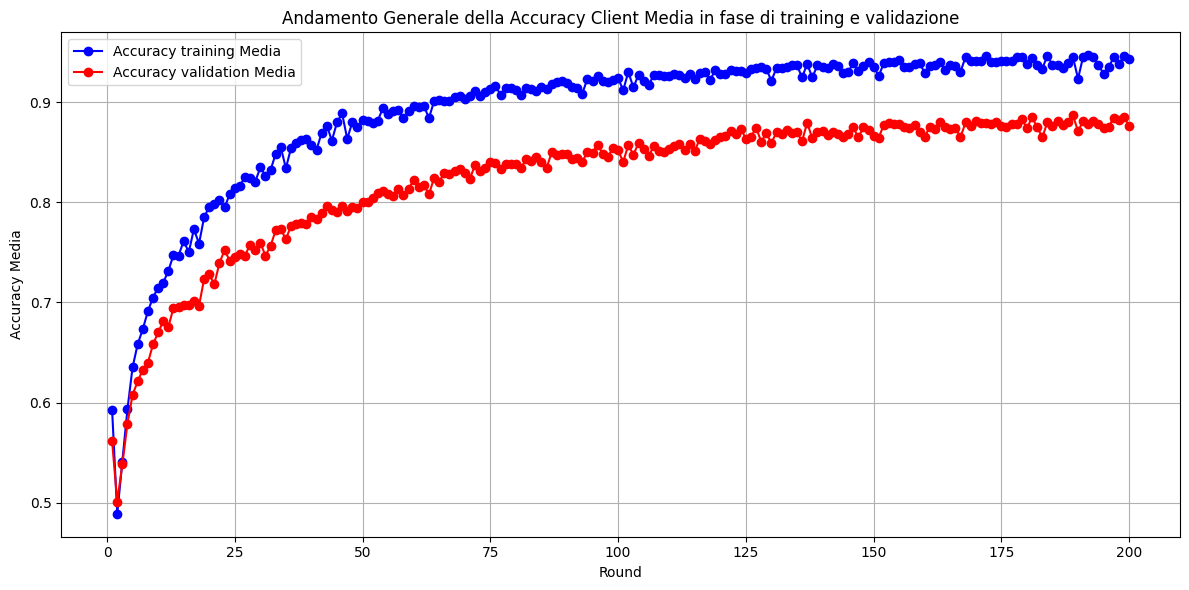

In [4]:
andamento_generale_medio_dei_client = "./results/andamento_generale_medio_dei_client/"
path = Path(andamento_generale_medio_dei_client)

if not path.is_dir():
    os.mkdir(path)

# if not os.mkdir("./results"):
#     os.mkdir("./results")
# os.mkdir(andamento_generale_medio_dei_client)
round_avg_loss = []

round_avg_accuracy = []
round_avg_val_loss = []
round_avg_val_acc =[]
for round_id, clients in clients_data.items():
    round_losses = []
    round_accuracies = []
    round_val_loss = []
    round_val_acc = []
    for client_id, metrics in clients.items():
        round_losses.append(np.mean(metrics["train_loss"]))
        round_accuracies.append(np.mean(metrics["train_acc"]))
        if np.mean(metrics["val_loss"]) >9:
            continue
        round_val_loss.append(np.mean(metrics["val_loss"]))
        round_val_acc.append(np.mean(metrics["val_acc"]))
    # Calcola la media della loss e dell'accuracy su tutti i client per il round corrente
    round_avg_loss.append(np.mean(round_losses))
    round_avg_accuracy.append(np.mean(round_accuracies))
    round_avg_val_acc.append(np.mean(round_val_acc))
    round_avg_val_loss.append(np.mean(round_val_loss))

# Creazione dei grafici
plt.figure(figsize=(12, 6))

# Grafico della loss media generale

plt.plot(range(1, len(round_avg_loss) + 1), round_avg_loss, marker='o',  color='b', label='Loss training Media')
plt.plot(range(1, len(round_avg_loss) + 1), round_avg_val_loss, marker='o',  color='r', label='Loss validation Media')
plt.xlabel('Round')
plt.ylabel('Loss Media')
plt.title('Andamento Generale della Loss Client Media in fase di training e validazione')
plt.legend()
plt.grid(True)
plt.savefig(andamento_generale_medio_dei_client+"loss_media.png")
plt.show()

# Grafico dell'accuracy media generale
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(round_avg_accuracy) + 1), round_avg_accuracy, marker='o',  color='b', label='Accuracy training Media')
plt.plot(range(1, len(round_avg_loss) + 1), round_avg_val_acc, marker='o',  color='r', label='Accuracy validation Media')
plt.xlabel('Round')
plt.ylabel('Accuracy Media')
plt.title('Andamento Generale della Accuracy Client Media in fase di training e validazione')
plt.legend()
plt.grid(True)
plt.savefig(andamento_generale_medio_dei_client+"accuracy_media.png")

plt.show()



In [5]:
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE
##SERVER SIDE


ACCURACY E LOSS MEDIA LATO SERVER

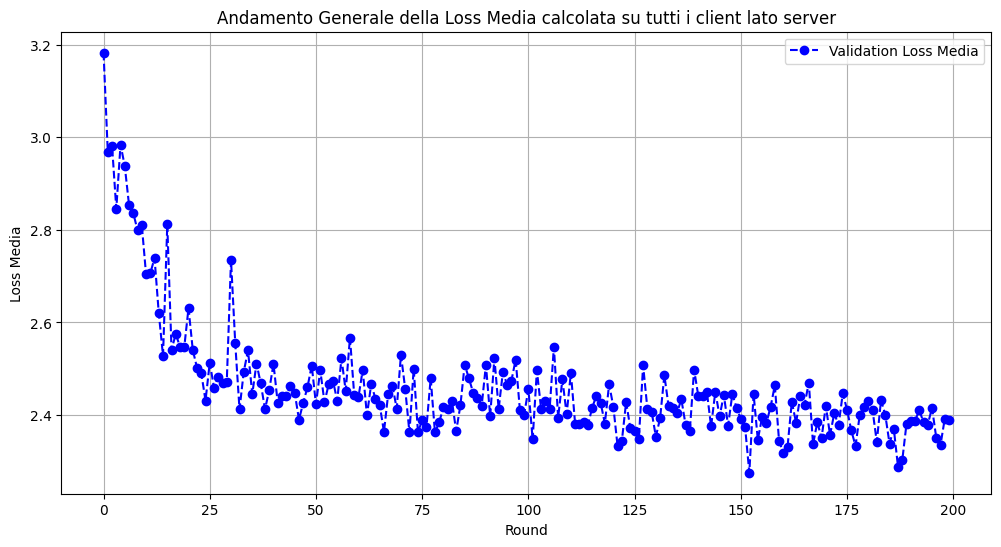

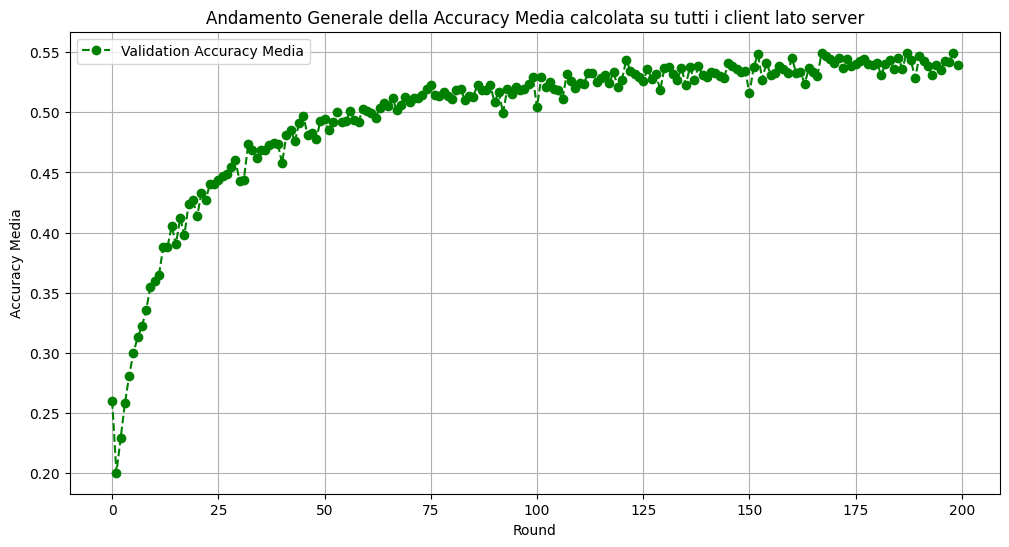

In [6]:
#ANDAMENTO MEDIO SU TUTTTI I CLIENT
andamento_generale_medio_dei_client_lato_server = "./results/andamento_generale_medio_dei_client_lato_server/"
path = Path(andamento_generale_medio_dei_client_lato_server)
if not path.is_dir():
    os.mkdir(path)


round_avg_val_loss = []
round_avg_val_acc =[]
for round_id, clients in server_data.items():

    round_val_loss = []
    round_val_acc = []
    for client_id, metrics in clients.items():

        round_val_loss.append(np.mean(metrics["loss"]))
        round_val_acc.append(np.mean(metrics["acc"]))
    # Calcola la media della loss e dell'accuracy su tutti i client per il round corrente
  
    round_avg_val_acc.append(np.mean(round_val_acc))
    round_avg_val_loss.append(np.mean(round_val_loss))

# Creazione dei grafici
plt.figure(figsize=(12, 6))

# Grafico della loss media generale
plt.plot(range( len(round_avg_val_loss) ), round_avg_val_loss, marker='o', linestyle='--', color='b', label='Validation Loss Media')
plt.xlabel('Round')
plt.ylabel('Loss Media')
plt.title('Andamento Generale della Loss Media calcolata su tutti i client lato server')
plt.legend()
plt.grid(True)
plt.savefig(andamento_generale_medio_dei_client_lato_server+"loss_media.png")
plt.show()

# Grafico dell'accuracy media generale
plt.figure(figsize=(12, 6))
plt.plot(range(len(round_avg_val_acc) ), round_avg_val_acc, marker='o', linestyle='--', color='g', label='Validation Accuracy Media')
plt.xlabel('Round')
plt.ylabel('Accuracy Media')
plt.title('Andamento Generale della Accuracy Media calcolata su tutti i client lato server')
plt.legend()
plt.grid(True)
plt.savefig(andamento_generale_medio_dei_client_lato_server+"accuracy_media.png")
plt.show()



In [7]:
# #ANDAMENTO MEDIO PER SINGOLO CLIENT
# client_avg_val_loss={}
# client_avg_val_acc={}
# # Itera su ogni round e client per calcolare la media
# for round_id, clients in server_data.items():
#     for client_id, metrics in clients.items():
#         if client_id not in client_avg_val_loss:
        
#             client_avg_val_loss[client_id] = []
#             client_avg_val_acc[client_id] = []
#         # Calcola la media delle loss e delle accuracy per ogni round
     

#         client_avg_val_loss[client_id].append(metrics["loss"])
#         client_avg_val_acc[client_id].append(metrics["acc"])

# rounds = range(1, len(next(iter(client_avg_val_loss.values()))) + 1)  # Numero di round


# # Plot della validation loss media per client
# for client_id in client_avg_val_loss.keys():
#     plt.figure(figsize=(12, 4))

#     plt.subplot(1, 2, 1)
#     plt.plot(rounds, client_avg_val_loss[client_id], label=f'Client {client_id}')
#     plt.xlabel("Round")
#     plt.ylabel("Validation Loss")
#     plt.title("Andamento della Validation Loss Media per Client")
#     plt.legend(loc="upper right", fontsize='small', ncol=2)
#     plt.grid()

#     plt.subplot(1, 2, 2)

#     plt.plot(rounds, client_avg_val_acc[client_id], label=f'Client {client_id}')
#     plt.xlabel("Round")
#     plt.ylabel("Validation Accuracy")
#     plt.title("Andamento della Validation Accuracy Media per Client")
#     plt.legend(loc="lower right", fontsize='small', ncol=2)
#     plt.grid()
#     plt.show()



CALCOLO METRICHE PER IL MODELLO GLOBALE SU SUL SERVER DATASET E TEST DATASET

In [13]:
import numpy as np
from torchvision.models import vgg11_bn,VGG11_BN_Weights 
import torch.nn as nn
from torch.utils.data import DataLoader
from scipy.special import lambertw
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import torch
import numpy as np
import random
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F
import os
import pandas as pd
from sklearn.model_selection import KFold
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
class PretrainedVGG11(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5,num_freeze_blocks=2):
        super(PretrainedVGG11, self).__init__()

        self.conv_block1 = self._make_conv_block(3, 64, 2)
        self.conv_block2 = self._make_conv_block(64, 128, 2)
        self.conv_block3 = self._make_conv_block(128, 256, 3)
        self.conv_block4 = self._make_conv_block(256, 512, 3)
        self.conv_block5 = self._make_conv_block(512, 512, 3)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )        
        for param in self.conv_block1.parameters():
            param.requires_grad = False
        for param in self.conv_block2.parameters():
            param.requires_grad = False


    def _make_conv_block(self, in_channels, out_channels, num_convs):
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))  # BatchNorm after the convolution
        layers.append(nn.ReLU())
        for _ in range(num_convs - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))  # BatchNorm after the convolution
            layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.conv_block5(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


In [3]:
def make_federated_data(    dataset,    num_clients=5,    alpha=0.5,    server_fraction=0.1,    batch_size=32,    shuffle=True,    seed=42,
                       save_path = None,num_workers=4):
 
    np.random.seed(seed)
    random.seed(seed)

    total_len = len(dataset)
    num_classes = 10  # se CIFAR-10
    os.makedirs(save_path, exist_ok=True)

    server_indices_path = os.path.join(save_path, 'server_indices.pt')
    client_indices_paths = [os.path.join(save_path, f'client_{i}_indices.pt') for i in range(num_clients)]
    
    indices_exist = os.path.exists(server_indices_path) and all(os.path.exists(path) for path in client_indices_paths)

    # ------------------------------------------------
    # 1) Selezioniamo i campioni per il server
    # ------------------------------------------------
    server_size = int(server_fraction * total_len)
    all_indices = list(range(total_len))
    
    if indices_exist:
        # Carica gli indici salvati
        server_indices = torch.load(server_indices_path)
        client_indices = []
        for path in client_indices_paths:
            client_indices.append(torch.load(path))
        print("[Info] Indici caricati dai file di split.")
    else:
        random.shuffle(all_indices)
        
        server_indices = all_indices[:server_size]
        client_indices_all = all_indices[server_size:]
        torch.save(server_indices, server_indices_path)
        print(f"[Info] Indici del server salvati in {server_indices_path}.")

        # ------------------------------------------------
        # 2) Raggruppiamo i rimanenti per classe
        # ------------------------------------------------
        indices_by_class = [[] for _ in range(num_classes)]
        for idx in client_indices_all:
            _, label = dataset[idx]
            indices_by_class[label].append(idx)

        # ------------------------------------------------
        # 3) Inizializziamo array per i client
        # ------------------------------------------------
        client_indices = [[] for _ in range(num_clients)]
    
        # Per tracciare la distribuzione {client: {classe: count}}
        agent_class_dist = {cid: {c: 0 for c in range(num_classes)} 
                            for cid in range(num_clients)}

        # ------------------------------------------------
        # 4) Partizione Dirichlet su ogni classe
        # ------------------------------------------------
        for c in range(num_classes):
            idxs_c = indices_by_class[c]
            random.shuffle(idxs_c)
            n_class = len(idxs_c)
            if n_class == 0:
                continue
    
            # estraiamo p ~ Dirichlet(alpha)
            proportions = np.random.dirichlet([alpha]*num_clients)
    
            # conteggi
            class_counts = (proportions * n_class).astype(int)
    
            gap = n_class - np.sum(class_counts)
            # distribuiamo l'eventuale gap
            while gap > 0:
                i = random.randint(0, num_clients-1)
                class_counts[i] += 1
                gap -= 1
    
            # Assegniamo i campioni di classe c
            start = 0
            for i in range(num_clients):
                count = class_counts[i]
                assigned_indices = idxs_c[start : start + count]
                client_indices[i].extend(assigned_indices)
                # Aggiorniamo la distribuzione
                agent_class_dist[i][c] += count
    
                start += count
        # Salva gli indici per ogni client
        for i in range(num_clients):
            torch.save(client_indices[i], client_indices_paths[i])
            print(f"[Info] Indici del client {i} salvati in {client_indices_paths[i]}.")
    # ------------------------------------------------
    # 5) Creiamo i DataLoader per i client
    # ------------------------------------------------
    client_loaders = []
    agent_classe = {}

    for i in range(num_clients):
        subset_i = Subset(dataset, client_indices[i])
        loader_i = DataLoader(subset_i, batch_size=batch_size, shuffle=shuffle,num_workers=num_workers)
        client_loaders.append(loader_i)
        class_counts = torch.zeros(num_classes, dtype=torch.long)

        total_per_client = len(subset_i)
        for _, labels in loader_i:
            # Conta le occorrenze di ciascuna classe nel batch
            batch_counts = torch.bincount(labels, minlength=num_classes)
            # Aggiungi i conteggi del batch al totale
            class_counts += batch_counts
        
        # Converti i conteggi in un dizionario
        distribution = {cls: int(count) for cls, count in enumerate(class_counts)}
        
        #approccio 1: ogni agente riceve sempre 10
        # agent_classe[i]=len(set(distribution.keys()))

        #approccio 2: ogni agente riceve il numero effettivo di classi, dove le istanze sono >0
        conta_classi = 0
        for key in distribution.keys():
            if distribution[key] >0:
                conta_classi+=1
        print(f"""[Client {i}] #campioni={total_per_client} -> Distribuzione classi:
        {distribution}""")
        agent_classe[i] = conta_classi
        

    server_subset = Subset(dataset, server_indices)
    server_loader = DataLoader(
        server_subset, batch_size=batch_size, shuffle=True,num_workers = num_workers
    )
    print(f"[Server] #campioni = {len(server_subset)} (fraction={server_fraction:.2f})")
    
    return client_loaders, server_loader, agent_classe


In [7]:
def extract_number(filename):
    numbers = re.findall(r'\d+', filename)  # Trova tutti i numeri nel nome del file
    return int(numbers[0]) if numbers else 0  # Converte il primo numero trovato in intero

In [8]:
def calculate_metrics(conf_matrix):
    y_true = []
    y_pred = []
    
    for true_label in range(10):
        for pred_label in range(10):
            count = conf_matrix[true_label, pred_label]
            y_true.extend([true_label] * count)
            y_pred.extend([pred_label] * count)
    
    
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(10), average='weighted', zero_division=0
    )
    return precision,recall,f1,accuracy

In [19]:
def load_checkpoint(filename:str):
    print(type(filename))
    print("=> Loading checkpoint")
    return  torch.load(filename)
base_folder = "TM20"    
test_case = 'base'
save_path = base_folder+'/dataloaders_indices'
num_clients = 25
server_data_fraction = 0.2 
batch_size = 32
alpha = 0.5
epochs = 20
num_rounds = 200
server_classes = 10
lambda_reg = 0.5
resume_from_checkpoint = False
check_point_name = """./checkpoint/80_checkpoint.pth.tar""",
round_resuming = None #none default

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_dataset =   CIFAR10(root=base_folder+'/datatest_test', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
distribution_server={}
for _, labels in test_loader:
    for label in labels:
        if int(label) in distribution_server:
            distribution_server[int(label)]+=1
        else:
            distribution_server[int(label)]= 1

measures ={}
check_point_name = """./checkpoint/80_checkpoint.pth.tar""",
files = sorted(os.listdir(base_folder+"/checkpoint/"), key=extract_number)
print(files)
for checkpoint in files:
    last_model = load_checkpoint(base_folder+"/checkpoint/"+checkpoint)
    CM = np.zeros((10, 10), dtype=int)

    round_num = int(checkpoint.split("_")[0])-1
    print(f"calcolo accuracy e loss round {round_num}")
    global_model = PretrainedVGG11(num_classes=10)
    device = 'cuda'
    global_model.load_state_dict(last_model['state_dict'])
    criterion = nn.CrossEntropyLoss()
    global_model.eval()
    
    global_model.to(device)
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = global_model(images)
            loss = criterion(outputs, labels)
            val_loss+=loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            CM+=confusion_matrix(labels.cpu().numpy(), predicted.cpu().numpy(),labels=range(10))
    precision,recall,f1,accuracy = calculate_metrics(CM)
    val_accuracy = val_correct / val_total  # Accuracy su validation set
    val_loss = val_loss/len(test_loader)
    measures[round_num] = {
                            'acc':val_accuracy,
                           'acc_auto':accuracy,
                           'loss':val_loss,
                            'precision':precision,
                            'recall':recall,
                            'f1':f1} 

Files already downloaded and verified
['1_checkpoint.pth.tar', '2_checkpoint.pth.tar', '3_checkpoint.pth.tar', '4_checkpoint.pth.tar', '5_checkpoint.pth.tar', '6_checkpoint.pth.tar', '7_checkpoint.pth.tar', '8_checkpoint.pth.tar', '9_checkpoint.pth.tar', '10_checkpoint.pth.tar', '11_checkpoint.pth.tar', '12_checkpoint.pth.tar', '13_checkpoint.pth.tar', '14_checkpoint.pth.tar', '15_checkpoint.pth.tar', '16_checkpoint.pth.tar', '17_checkpoint.pth.tar', '18_checkpoint.pth.tar', '19_checkpoint.pth.tar', '20_checkpoint.pth.tar', '21_checkpoint.pth.tar', '22_checkpoint.pth.tar', '23_checkpoint.pth.tar', '24_checkpoint.pth.tar', '25_checkpoint.pth.tar', '26_checkpoint.pth.tar', '27_checkpoint.pth.tar', '28_checkpoint.pth.tar', '29_checkpoint.pth.tar', '30_checkpoint.pth.tar', '31_checkpoint.pth.tar', '32_checkpoint.pth.tar', '33_checkpoint.pth.tar', '34_checkpoint.pth.tar', '35_checkpoint.pth.tar', '36_checkpoint.pth.tar', '37_checkpoint.pth.tar', '38_checkpoint.pth.tar', '39_checkpoint.pth.t

/tmp/ipykernel_2778632/2328476913.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


calcolo accuracy e loss round 0
<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 1


/tmp/ipykernel_2778632/2328476913.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint


...

/tmp/ipykernel_2778632/2328476913.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 67


/tmp/ipykernel_2778632/2328476913.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 68


/tmp/ipykernel_2778632/2328476913.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


In [20]:
accuracy_values = [x['acc'] for x in measures.values()]
accuracy_auto = [x['acc_auto'] for x in measures.values()]
loss_values= [x['loss'] for x in measures.values()]
precision_val = [x['precision'] for x in measures.values()]
recall_val = [x['recall'] for x in measures.values()]
f1_val = [x['f1'] for x in measures.values()]

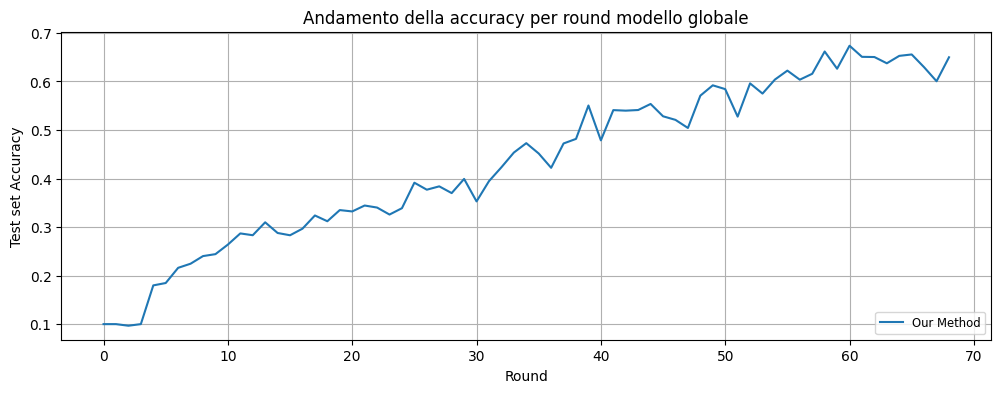

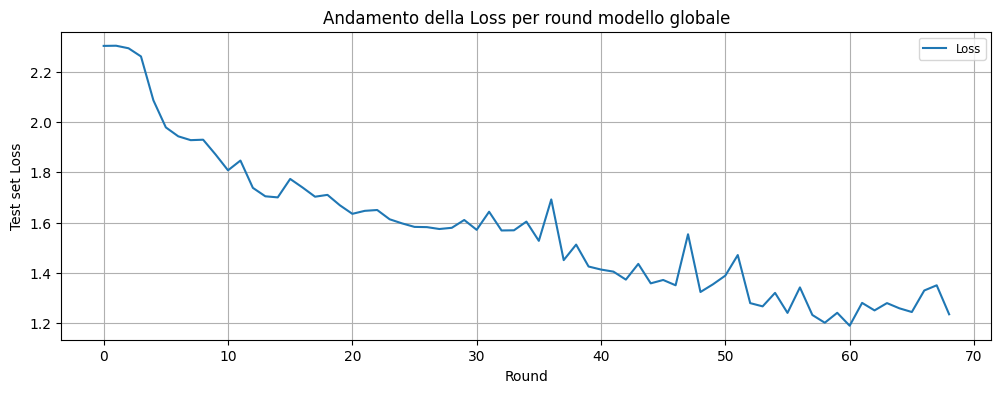

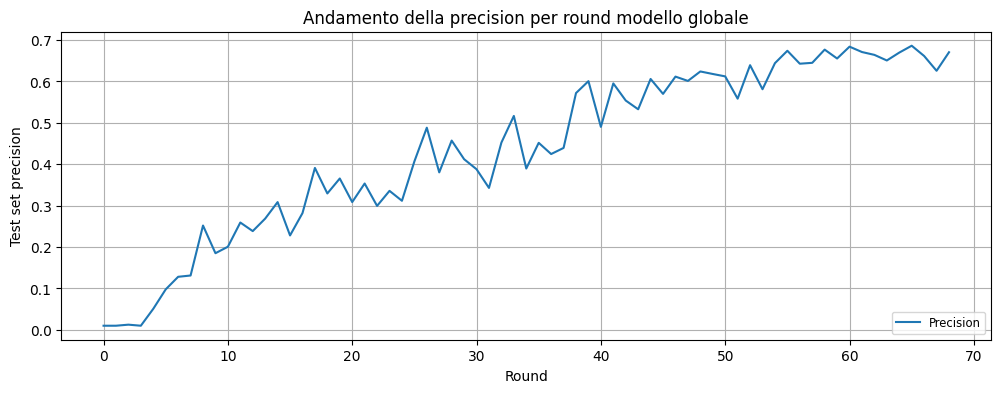

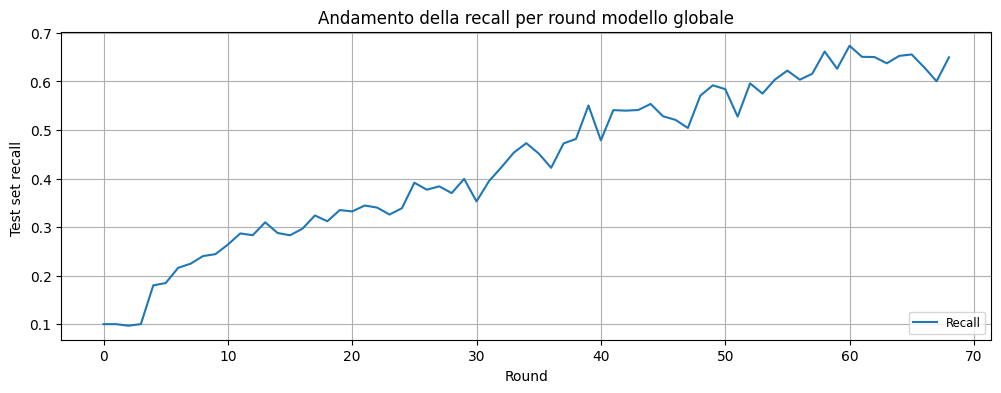

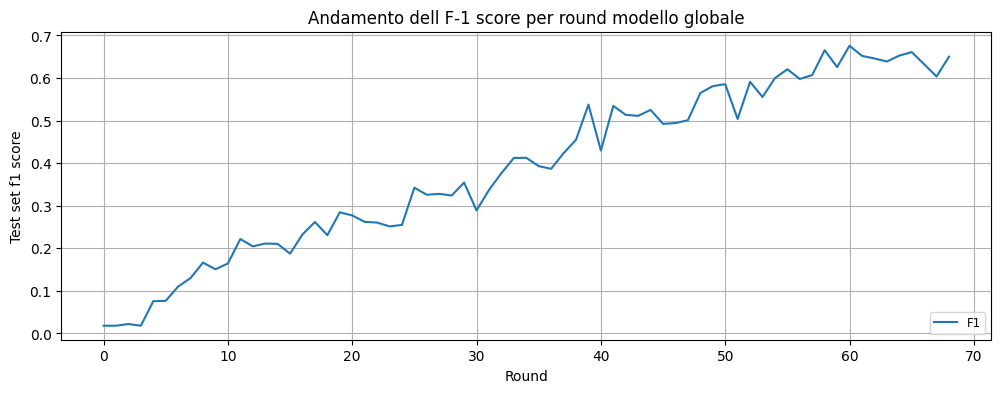

In [21]:
andamento_modello_globale_test_set ="./results/andamento_modello_globale_test_set/"
path = Path(andamento_modello_globale_test_set)
if not path.is_dir():
    os.mkdir(path)


plt.figure(figsize=(12, 4))
plt.plot(measures.keys(),accuracy_values, label=f'Our Method')
plt.xlabel("Round")
plt.ylabel("Test set Accuracy")
plt.title("Andamento della accuracy per round modello globale")
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid()
# plt.savefig(andamento_modello_globale_test_set+"accuracy.png")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(measures.keys(), loss_values, label=f'Loss')
plt.xlabel("Round")
plt.ylabel("Test set Loss")
plt.title("Andamento della Loss per round modello globale")
plt.legend(loc="upper right", fontsize='small', ncol=2)
plt.grid()
# plt.savefig(andamento_modello_globale_test_set+"loss.png")

plt.show()


# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.plot(measures.keys(), accuracy_auto, label=f'Loss')
# plt.xlabel("Round")
# plt.ylabel("Test accuracy auto")
# plt.title("Andamento della Accuracy Auto per round ")
# plt.legend(loc="upper right", fontsize='small', ncol=2)
# plt.grid()
# plt.savefig(andamento_modello_globale_test_set+"accuracy_auto.png")

plt.figure(figsize=(12, 4))
plt.plot(measures.keys(), precision_val, label=f'Precision')
plt.xlabel("Round")
plt.ylabel("Test set precision")
plt.title("Andamento della precision per round modello globale")
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid()
# plt.savefig(andamento_modello_globale_test_set+"precision.png")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(measures.keys(), recall_val, label=f'Recall')
plt.xlabel("Round")
plt.ylabel("Test set recall ")
plt.title("Andamento della recall per round modello globale")
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid()
plt.savefig(andamento_modello_globale_test_set+"recall.png")
plt.show()
plt.figure(figsize=(12, 4))

plt.plot(measures.keys(), f1_val, label=f'F1')
plt.xlabel("Round")
plt.ylabel("Test set f1 score")
plt.title("Andamento dell F-1 score per round modello globale")
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid()
# plt.savefig(andamento_modello_globale_test_set+"f1.png")

plt.show()

Server SET

In [18]:
measures_server ={}
check_point_name = """./checkpoint/80_checkpoint.pth.tar""",
files = sorted(os.listdir("./checkpoint/"), key=extract_number)

for checkpoint in files:
    last_model = load_checkpoint("./checkpoint/"+checkpoint)
    CM = np.zeros((10, 10), dtype=int)

    round_num = int(checkpoint.split("_")[0])-1
    print(f"calcolo accuracy e loss round {round_num}")
    global_model = PretrainedVGG11(num_classes=10)
    device = 'cuda'
    global_model.load_state_dict(last_model['state_dict'])
    criterion = nn.CrossEntropyLoss()
    global_model.eval()
    
    global_model.to(device)
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for images, labels in server_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = global_model(images)
            loss = criterion(outputs, labels)
            val_loss+=loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            CM+=confusion_matrix(labels.cpu().numpy(), predicted.cpu().numpy(),labels=range(10))
    precision,recall,f1,accuracy = calculate_metrics(CM)
    val_accuracy = val_correct / val_total  # Accuracy su validation set
    val_loss = val_loss/len(test_loader)
    measures_server[round_num] = {
                            'acc':val_accuracy,
                           'acc_auto':accuracy,
                           'loss':val_loss,
                            'precision':precision,
                            'recall':recall,
                            'f1':f1}

<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 0


/tmp/ipykernel_3134403/22497985.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 1


/tmp/ipykernel_3134403/22497985.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 2


...

/tmp/ipykernel_3134403/22497985.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 198


/tmp/ipykernel_3134403/22497985.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


<class 'str'>
=> Loading checkpoint
calcolo accuracy e loss round 199


/tmp/ipykernel_3134403/22497985.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return  torch.load(filename)


In [19]:
accuracy_values_server = [x['acc'] for x in measures_server.values()]
accuracy_auto_server = [x['acc_auto'] for x in measures_server.values()]
loss_values_server = [x['loss'] for x in measures_server.values()]
precision_val_server = [x['precision'] for x in measures_server.values()]
recall_val_server = [x['recall'] for x in measures_server.values()]
f1_val_server = [x['f1'] for x in measures_server.values()]

Shape of extracted weights: (64, 3, 3, 3)


/home/habes/anaconda3/envs/llmenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


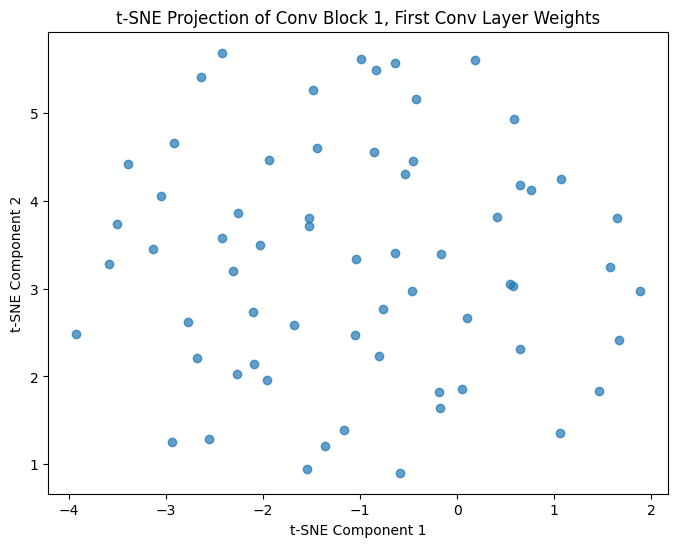

In [12]:


# Instantiate your model
model = PretrainedVGG11(num_classes=10, dropout_rate=0.5)
model.eval()  # Set the model to evaluation mode

# --- Extracting Weights from a Convolutional Layer ---

# Here we choose the first convolutional layer in conv_block1.
# If you want the second conv layer in conv_block1, change the index to 3.
conv_layer = model.conv_block1[0]  # nn.Conv2d layer
weights = conv_layer.weight.data.cpu().numpy()  # shape: (num_filters, in_channels, height, width)
print("Shape of extracted weights:", weights.shape)
# For example, this might print: (64, 3, 3, 3)

# Flatten each filter into a 1D vector
num_filters = weights.shape[0]
weights_flat = weights.reshape(num_filters, -1)  # Now each filter is a vector of length (in_channels * height * width)

# --- Preprocessing (Optional but Recommended) ---

# Standardize the weight vectors. This can help t-SNE by putting the data on a similar scale.
scaler = StandardScaler()
weights_flat_scaled = scaler.fit_transform(weights_flat)

# --- Apply t-SNE ---

# Initialize and fit t-SNE to reduce to 2 dimensions.
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
weights_tsne = tsne.fit_transform(weights_flat_scaled)

# --- Visualize with a Scatter Plot ---

plt.figure(figsize=(8, 6))
plt.scatter(weights_tsne[:, 0], weights_tsne[:, 1], alpha=0.7)
plt.title("t-SNE Projection of Conv Block 1, First Conv Layer Weights")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()
